In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [3]:
# Loading the housing dataset
df = pd.read_csv('Housing.csv')

## Exploration

In [5]:
# First look at the data
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
# Checking dtypes and null counts

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


Price ranges from 1.75M to 13.3M - that's a wide spread
Area also has a big range (1650 to 16200), which will need attention later

In [8]:
df.shape

(545, 13)

In [9]:

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Confirming no nulls - we won't need to impute anything

In [ ]:

df.nunique().sort_values(ascending=False)

area                284
price               219
bedrooms              6
bathrooms             4
stories               4
parking               4
furnishingstatus      3
mainroad              2
guestroom             2
hotwaterheating       2
basement              2
airconditioning       2
prefarea              2
dtype: int64

Checking how many unique values each column has

Area (284) and price (219) are essentially continuous

## Visualizations

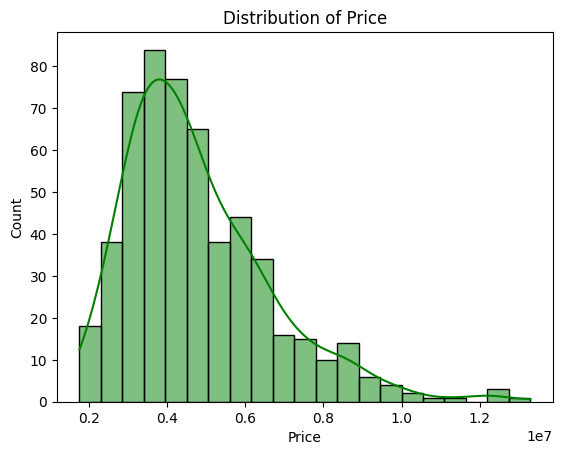

In [11]:
# Price distribution
sns.histplot(df['price'], kde=True, color='green')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

Most houses cluster in the lower price range, fewer very expensive ones

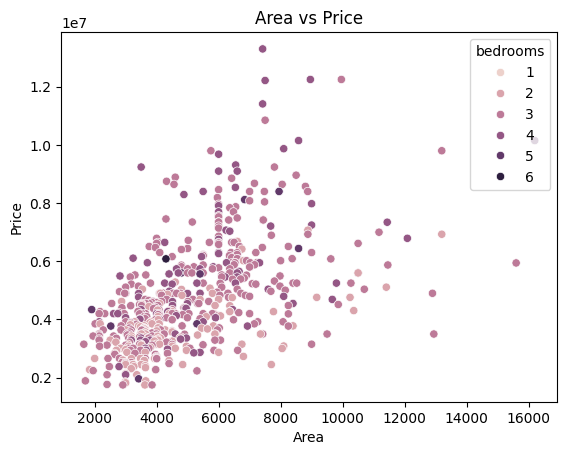

In [12]:
# Area vs price scatter plot
sns.scatterplot(x='area', y='price', data=df, hue='bedrooms')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

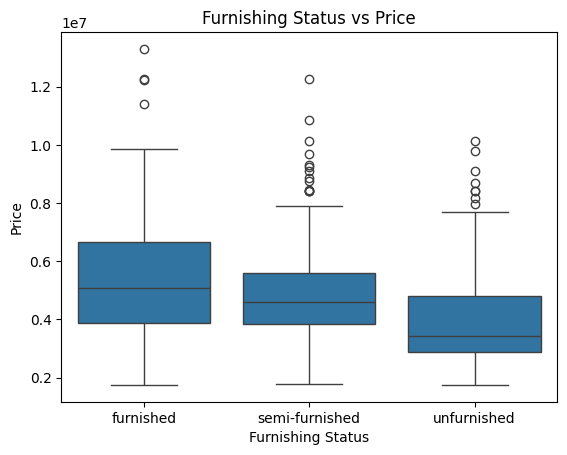

In [13]:
sns.boxplot(x='furnishingstatus', y='price', data=df)
plt.title('Furnishing Status vs Price')
plt.xlabel('Furnishing Status')
plt.ylabel('Price')
plt.show()

Furnished homes tend to be priced higher than semi-furnished or unfurnished

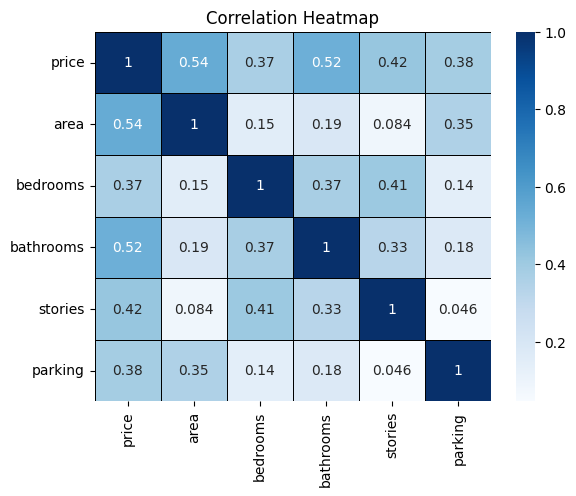

In [14]:
# Correlation heatmap for numerical features only
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', linecolor='black', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Area and bathrooms have the strongest correlation with price

## Preprocessing

In [15]:
# Converting yes/no columns to 1/0
bin_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in bin_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [16]:
# furnishingstatus has 3 categories so binary mapping won't work - using one-hot encoding instead
# furnished becomes the reference category, we get semi-furnished and unfurnished as columns
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = encoder.fit_transform(df[['furnishingstatus']])
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['furnishingstatus']))
df = pd.concat([df, encoded_df], axis=1)
df.drop('furnishingstatus', axis=1, inplace=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0.0,0.0


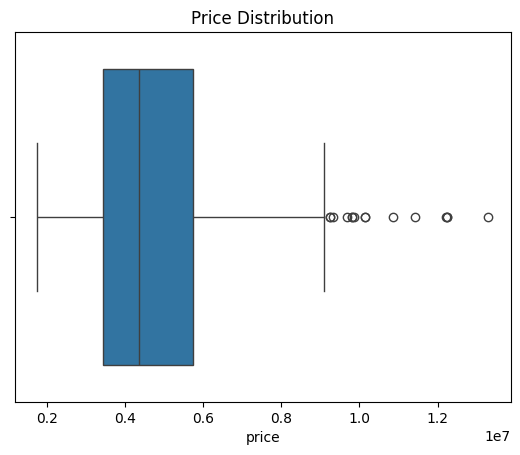

In [17]:
# Checking for outliers visually before deciding what to do with them
sns.boxplot(data=df, x='price')
plt.title('Price Distribution')
plt.show()

In [18]:
# Capping price at 95th percentile instead of dropping rows
# This keeps all 545 samples while reducing the influence of extreme values on the model
upper = df['price'].quantile(0.95)
df['price'] = df['price'].clip(upper=upper)

In [19]:
upper = df['area'].quantile(0.95)
df['area'] = df['area'].clip(upper=upper)

## Model Training

In [21]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Scaling is important here because area and binary columns are on very different scales

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Training the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
# Predicting on test set
Y_pred = model.predict(X_test_scaled)

In [ ]:
# Evaluating the model
mae = mean_absolute_error(y_test, Y_pred)
print(f'Mean Absolute Error: {round(mae, 2)}')

rmse = root_mean_squared_error(y_test, Y_pred)
print(f'Root Mean Squared Error: {round(rmse, 2)}')

r2 = r2_score(y_test, Y_pred)
print(f'R-squared: {round(r2, 2)}')

Mean Absolute Error: 846990.0
Root Mean Squared Error: 1066336.27
R-squared: 0.68
